# Task 1 — Maze Mapping and Dijkstra Path Planning

This notebook is only an interface over the existing Python modules. It does not reimplement or change the masking, clip-grid, graph, Dijkstra, or L/F/R logic.

Run the cells from top to bottom. Change only the values in the **Configuration** cell for a different image, start node, or goal node.

In [31]:
from pathlib import Path
import sys

import cv2
import matplotlib.pyplot as plt

# Work whether Jupyter was started in the repository root or mazemapping/.
WORKING_DIRECTORY = Path.cwd()
MAZE_DIRECTORY = (
    WORKING_DIRECTORY
    if (WORKING_DIRECTORY / 'mask_maze.py').is_file()
    else WORKING_DIRECTORY / 'mazemapping'
)
if not (MAZE_DIRECTORY / 'mask_maze.py').is_file():
    raise FileNotFoundError('Open this notebook from the repository root or mazemapping folder.')

sys.path.insert(0, str(MAZE_DIRECTORY))

from clip_grid import infer_clip_grid
from mask_maze import create_board_mask, create_maze_masks
from path_planning_nodes import (
    add_clearance,
    draw_nodes,
    ensure_binary_planning_map,
    generate_fixed_grid_nodes,
    generate_nodes_from_positions,
)
from shortest_path_dijkstra import (
    build_collision_free_graph,
    dijkstra_shortest_path,
    draw_graph_and_path,
    nearest_traversable_node,
)
from path_to_lfr import path_to_lfr_commands, compress_forward_commands

print(f'Maze directory: {MAZE_DIRECTORY.resolve()}')

Maze directory: /Users/jy17/mtrn3100/micromouse3100/mazemapping


## Image and grid configuration

Choose the image and grid method first. After the numbered grid is displayed below, choose the start and goal nodes in the separate route cell. `GRID_FROM_CLIPS = False` restores the original fixed-inset grid.

In [ ]:
# IMAGE_NAME = 'friday_maze.png'
IMAGE_NAME = 'monday_offical.png'

# IMAGE_NAME = 'thursday_maze.png'

# IMAGE_NAME = 'Screenshot 2026-08-04 103907.png'
# IMAGE_NAME =  'Screenshot 2026-08-04 105903.png'


ROWS = 9
COLUMNS = 9
GRID_FROM_CLIPS = True
INSET_X = 0.08       # used only when GRID_FROM_CLIPS is False
INSET_Y = 0.08       # used only when GRID_FROM_CLIPS is False
CLEARANCE_PIXELS = 0
EDGE_CHECK_THICKNESS = 3
SHOW_NODE_LABELS = True

IMAGE_PATH = MAZE_DIRECTORY / IMAGE_NAME
print(f'Image: {IMAGE_PATH}')

Image: /Users/jy17/mtrn3100/micromouse3100/mazemapping/monday_2.png


## Load the image and create the existing planning mask

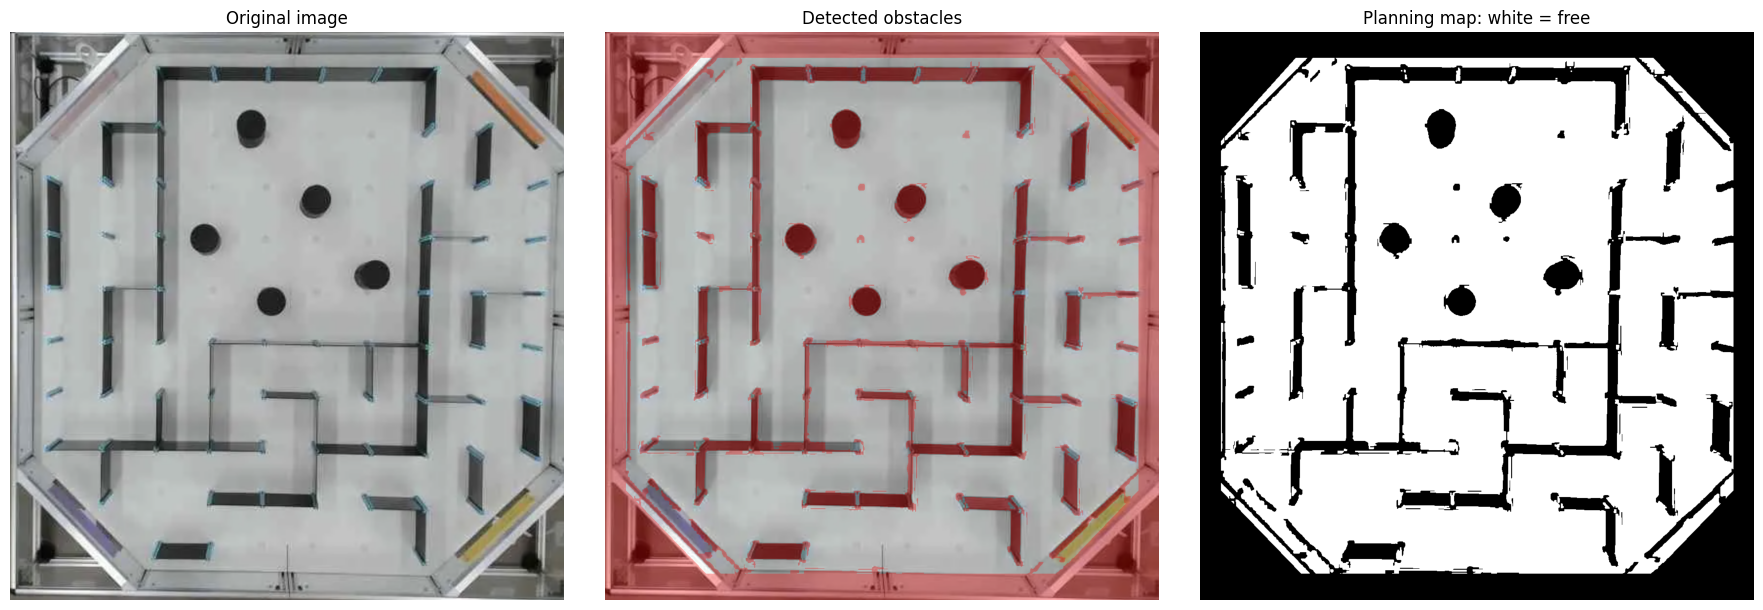

In [33]:
if not IMAGE_PATH.is_file():
    raise FileNotFoundError(f'Maze image not found: {IMAGE_PATH}')

original_image = cv2.imread(str(IMAGE_PATH), cv2.IMREAD_COLOR)
if original_image is None:
    raise ValueError(f'OpenCV could not read: {IMAGE_PATH}')

mask_outputs = create_maze_masks(original_image)
planning_map = ensure_binary_planning_map(
    mask_outputs['07_planning_map_free_white.png']
)
safe_planning_map = add_clearance(planning_map, CLEARANCE_PIXELS)
height, width = safe_planning_map.shape
board_mask, _ = create_board_mask(height, width)

figure, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original image')
axes[1].imshow(mask_outputs['08_mask_overlay.png'][:, :, ::-1])
axes[1].set_title('Detected obstacles')
axes[2].imshow(safe_planning_map, cmap='gray', vmin=0, vmax=255)
axes[2].set_title('Planning map: white = free')
for axis in axes:
    axis.axis('off')
plt.tight_layout()
plt.show()

## Generate nodes using the selected existing method

In [34]:
if GRID_FROM_CLIPS:
    clip_grid_result = infer_clip_grid(
        image=original_image,
        rows=ROWS,
        columns=COLUMNS,
    )
    nodes = generate_nodes_from_positions(
        planning_map=safe_planning_map,
        board_mask=board_mask,
        rows=ROWS,
        columns=COLUMNS,
        positions=clip_grid_result.node_positions,
    )
    print(
        f'Clip grid: {len(clip_grid_result.clip_centres)} detections, '
        f'{clip_grid_result.inlier_count} inliers, '
        f'{clip_grid_result.median_fit_error:.2f}px median error'
    )
else:
    clip_grid_result = None
    nodes = generate_fixed_grid_nodes(
        planning_map=safe_planning_map,
        board_mask=board_mask,
        rows=ROWS,
        columns=COLUMNS,
        inset_x_fraction=INSET_X,
        inset_y_fraction=INSET_Y,
    )
    print(f'Fixed grid: inset-x={INSET_X}, inset-y={INSET_Y}')

blocked_node_ids = [node.node_id for node in nodes if node.blocked]
print(f'Blocked node IDs: {blocked_node_ids}')

Clip grid: 57 detections, 35 inliers, 2.46px median error
Blocked node IDs: [0, 8, 72, 80]


## View the numbered grid before choosing start and goal

Use this image to choose node IDs. Green nodes are free and red nodes are blocked. The thin grid lines are candidate neighbour connections only; wall collision checking happens afterward.

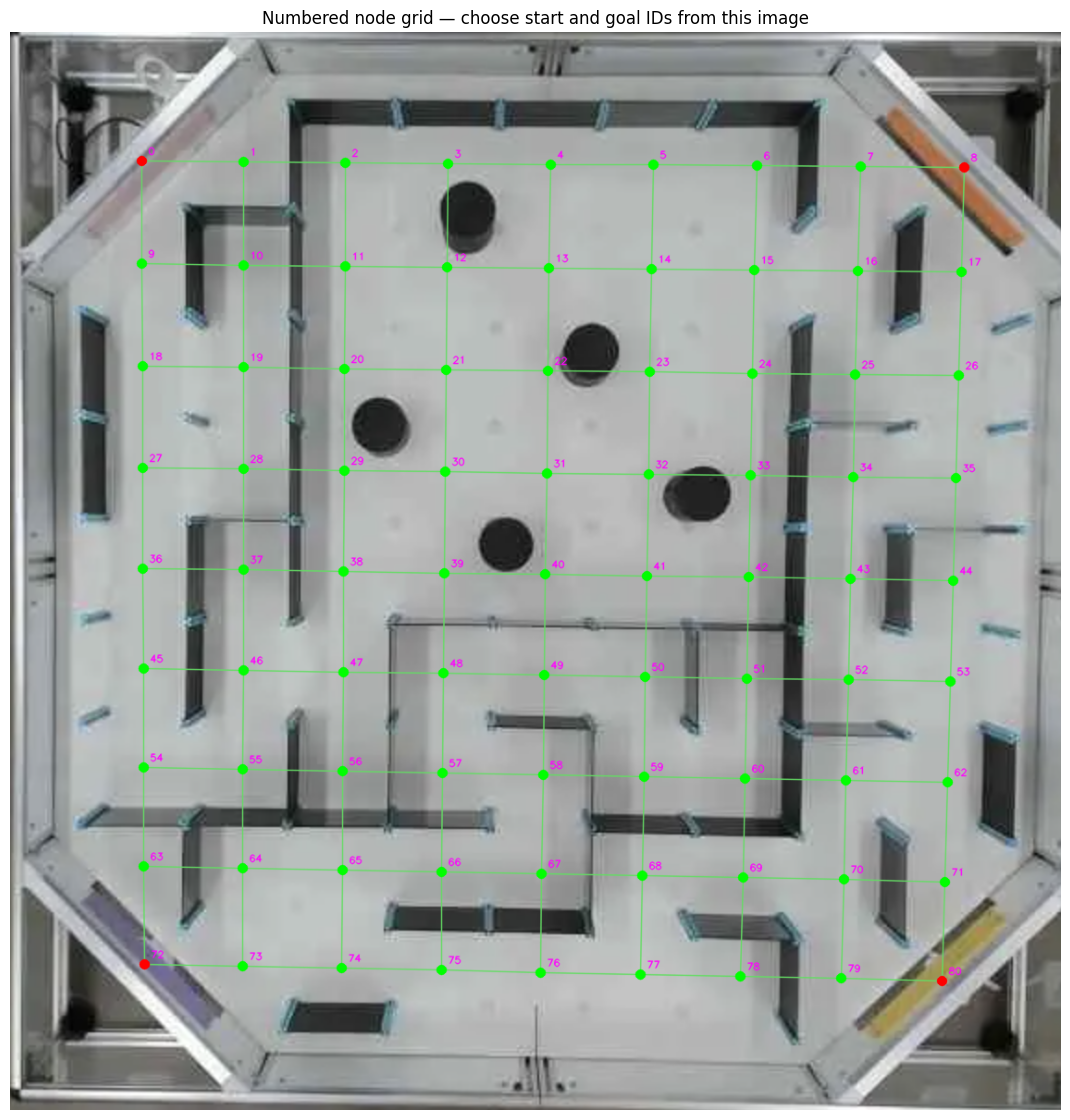

In [35]:
numbered_grid_preview = draw_nodes(
    base_image=original_image,
    nodes=nodes,
    rows=ROWS,
    columns=COLUMNS,
    radius=5,
    show_labels=True,
)

plt.figure(figsize=(14, 14))
plt.imshow(cv2.cvtColor(numbered_grid_preview, cv2.COLOR_BGR2RGB))
plt.title('Numbered node grid — choose start and goal IDs from this image')
plt.axis('off')
plt.show()

## Select the route

After viewing the grid above, enter the desired start and goal node IDs here.

In [36]:
START_NODE = 2
GOAL_NODE = 79
INITIAL_HEADING = 'up'  # up, right, down, or left

print(f'Requested route: {START_NODE} -> {GOAL_NODE}')
print(f'Initial heading: {INITIAL_HEADING}')

Requested route: 2 -> 79
Initial heading: up


## Build the existing graph and run Dijkstra

In [37]:
graph = build_collision_free_graph(
    nodes=nodes,
    planning_map=safe_planning_map,
    rows=ROWS,
    columns=COLUMNS,
    edge_check_thickness=EDGE_CHECK_THICKNESS,
)

start_node = nearest_traversable_node(START_NODE, nodes, graph)
goal_node = nearest_traversable_node(GOAL_NODE, nodes, graph)

if start_node.node_id != START_NODE:
    print(f'WARNING: requested start {START_NODE} is blocked or isolated; using {start_node.node_id}.')
if goal_node.node_id != GOAL_NODE:
    print(f'WARNING: requested goal {GOAL_NODE} is blocked or isolated; using {goal_node.node_id}.')

path, total_distance = dijkstra_shortest_path(
    graph,
    start_node.node_id,
    goal_node.node_id,
)

valid_edge_count = sum(len(neighbours) for neighbours in graph.values()) // 2
print(f'Traversable graph nodes: {len(graph)}')
print(f'Valid undirected edges: {valid_edge_count}')
if path:
    print('Path:', ' -> '.join(str(node_id) for node_id in path))
    print(f'Moves: {len(path) - 1}')
    print(f'Path length: {total_distance:.2f} pixels')
else:
    print(f'NO PATH between resolved nodes {start_node.node_id} and {goal_node.node_id}.')

Traversable graph nodes: 77
Valid undirected edges: 89
Path: 2 -> 11 -> 12 -> 13 -> 14 -> 15 -> 16 -> 25 -> 26 -> 35 -> 34 -> 43 -> 52 -> 53 -> 62 -> 61 -> 70 -> 79
Moves: 17
Path length: 1874.31 pixels


## Display the graph and shortest path

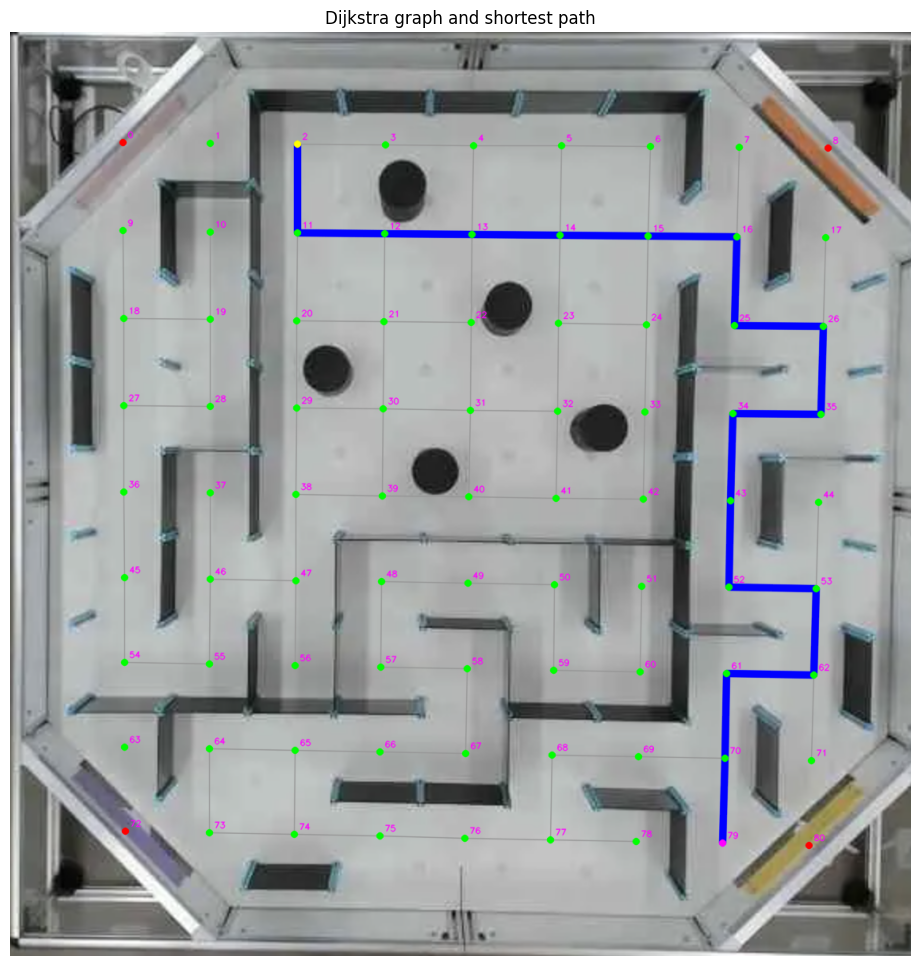

In [38]:
path_preview = draw_graph_and_path(
    original_image=original_image,
    nodes=nodes,
    graph=graph,
    path=path,
    start_id=start_node.node_id,
    goal_id=goal_node.node_id,
    show_labels=SHOW_NODE_LABELS,
)

plt.figure(figsize=(12, 12))
plt.imshow(cv2.cvtColor(path_preview, cv2.COLOR_BGR2RGB))
plt.title('Dijkstra graph and shortest path')
plt.axis('off')
plt.show()

## Convert the path to the existing L/F/R commands

In [39]:
if path:
    commands, absolute_directions = path_to_lfr_commands(
        path=path,
        nodes=nodes,
        initial_heading=INITIAL_HEADING,
    )
    print('Initial heading:', INITIAL_HEADING)
    print('Absolute directions:', ' -> '.join(absolute_directions))
    print('Command string:', ''.join(commands))
    print('Spaced commands:', ' '.join(commands))
    print('Compressed commands:', compress_forward_commands(commands))
else:
    print('No L/F/R commands because Dijkstra did not find a path.')

Initial heading: up
Absolute directions: down -> right -> right -> right -> right -> right -> down -> right -> down -> left -> down -> down -> right -> down -> left -> down -> down
Command string: rrflfffffrflfrfrflfflfrfrflff
Spaced commands: r r f l f f f f f r f l f r f r f l f f l f r f r f l f f
Compressed commands: r r f l f5 r f l f r f r f l f2 l f r f r f l f2


## Optional diagnostics for one node

Change `NODE_TO_INSPECT` to see whether a node is blocked or isolated and list its graph neighbours.

In [40]:
NODE_TO_INSPECT = GOAL_NODE
node = nodes[NODE_TO_INSPECT]
neighbour_ids = [node_id for node_id, _ in graph.get(NODE_TO_INSPECT, [])]
print(f'Node {NODE_TO_INSPECT}')
print(f'  row/column: ({node.row}, {node.column})')
print(f'  image coordinate: ({node.x}, {node.y})')
print(f'  blocked: {node.blocked}')
print(f'  neighbours: {neighbour_ids}')
print(f'  isolated: {not node.blocked and len(neighbour_ids) == 0}')

Node 79
  row/column: (8, 7)
  image coordinate: (898, 1023)
  blocked: False
  neighbours: [70]
  isolated: False
